In [430]:
import json
import os
from pathlib import Path
from unicodedata import category
import pandas as pd
import duckdb
import statistics
import pandas as pd
import duckdb
import numpy as np
import functools
import pyro
import matplotlib
import matplotlib.pyplot as plt
import functools
from IPython.core.pylabtools import figsize
from sympy import false
from tornado.escape import json_decode
import seaborn as sns

In [431]:
li = list(matplotlib.font_manager.get_font_names())
li.sort()
li

['.Aqua Kana',
 '.CJK Symbols Fallback HK',
 '.DecoType Nastaleeq Urdu UI',
 '.Keyboard',
 '.New York',
 '.SF Arabic',
 '.SF Arabic Rounded',
 '.SF Armenian',
 '.SF Armenian Rounded',
 '.SF Camera',
 '.SF Compact',
 '.SF Compact Rounded',
 '.SF Georgian',
 '.SF Georgian Rounded',
 '.SF Hebrew',
 '.SF Hebrew Rounded',
 '.SF NS Mono',
 '.SF NS Rounded',
 '.SF Numeric',
 '.ThonburiUI',
 'Academy Engraved LET',
 'Adelle Sans Devanagari',
 'AkayaKanadaka',
 'AkayaTelivigala',
 'Al Bayan',
 'Al Nile',
 'Al Tarikh',
 'American Typewriter',
 'Andale Mono',
 'Annai MN',
 'Apple Braille',
 'Apple Chancery',
 'Apple LiGothic',
 'Apple LiSung',
 'Apple SD Gothic Neo',
 'Apple Symbols',
 'AppleGothic',
 'AppleMyungjo',
 'Arial',
 'Arial Black',
 'Arial Hebrew',
 'Arial Narrow',
 'Arial Rounded MT Bold',
 'Arial Unicode MS',
 'Arima Koshi',
 'Arima Madurai',
 'Athelas',
 'Avenir',
 'Avenir Next',
 'Avenir Next Condensed',
 'Ayuthaya',
 'BIZ UDGothic',
 'BIZ UDMincho',
 'BM Dohyeon',
 'BM Hanna 11yrs

In [432]:
import matplotlib
matplotlib.rc('font', family='Arial Unicode Ms')

In [433]:
df_sess = pd.read_parquet('../../data/processed/irt_session.parquet')
df_sess['section_name']  = df_sess['section_name']
df_sess.value_counts('session_id')

session_id
1.0      68779
2.0      31102
3.0      14460
4.0       7930
5.0       4975
         ...  
108.0        1
107.0        1
106.0        1
105.0        1
122.0        1
Name: count, Length: 122, dtype: int64

In [434]:
# 限制answer length 大於18 (6個ability)
df_sess : pd.DataFrame = df_sess[df_sess["answer_length"] >= 18]

# 先按 user + start_time 排好時間順序
df_sess : pd.DataFrame = df_sess.sort_values(["user_id", "start_time"])

df_sess = df_sess.drop_duplicates(['user_id','section_name'],keep='first')

df_sess['difficulty_level_chunk'] = df_sess['difficulty_level'].apply(lambda lis :  [lis[i:i+3] for i in range(0,len(lis),3)] )
df_sess['question_id_chunk'] =      df_sess['question_id'].apply(lambda lis :       [lis[i:i+3] for i in range(0,len(lis),3)] )
df_sess['is_correct_chunk'] =       df_sess['is_correct'].apply(lambda lis :        [lis[i:i+3] for i in range(0,len(lis),3)] )
df_sess.user_id.nunique()

3265

In [435]:
# load section 排序

with open('../../data/processed/top_section_lis.json','r') as f:
    top_section_list = json.load(f)
print(top_section_list)
len(top_section_list)

['2 因數與倍數', '10 柱體、錐體和球', '6 異分母分數的加減', '2+3 因數與公因數、倍數與公倍數', '4 擴分、約分和通分', '1 小數的加減', '5 線對稱圖形', '2 因數和倍數', '1 體積', '5 多邊形與扇形', '9 面積', '9 時間的乘除', '8 面積', '2 分數的計算', '1 多位小數與加減', '9 比率與百分率', '4 多邊形與扇形', '7 線對稱圖形', '7 整數四則運算', '8 平行四邊形、三角形和梯形的面積', '3 多邊形', '8 整數四則運算', '3 容積', '7 列式與解題', '3 擴分、約分和通分', '6 乘法和除法', '5 異分母分數的加減', '6 整數、小數除以整數', '7 整數四則計算', '8 表面積', '10 生活中的單位與換算', '7 柱體、錐體和球體', '4 小數的乘法', '3 平面圖形', '8 比率和百分率', '1 多位小數', '1 乘法和除法', '6 生活中的大單位', '1 分數的乘法', '2 倍數與因數', '4 平面圖形', '4 正方體和長方體', '10 怎樣列式', '10 小數的加減', '9 容積和容量', '2 因數與公因數', '10 線對稱圖形', '3 扇形', '10 立體形體', '6 表面積', '6 擴分、約分和通分', '4 公倍數與公因數', '3 倍數與公倍數', '7 小數', '2 小數的乘法', '1 分數', '6 整數四則運算', '8 四則運算', '7 異分母分數的加減', '5 符號代表數', '7 擴、約分與加減', '8 生活中的大單位', '2 長方體和正方體的體積', '5 多位數的乘除', '4 時間的計算', '5 整數、小數除以整數', '9 乘以幾分之一']


67

In [436]:

df_sess = df_sess.explode(['difficulty_level_chunk','question_id_chunk','is_correct_chunk'])

df_sess['chunk_order_'] = 1
df_sess['chunk_order'] = df_sess.groupby(['user_id','section_name'])['chunk_order_'].cumcount()


In [437]:
df_sess['is_correct'] = df_sess['is_correct_chunk']
df_sess['difficulty_level'] = df_sess['difficulty_level_chunk']
df_sess['question_id'] = df_sess['question_id_chunk']
df_sess['block_idx'] = df_sess['chunk_order']
df_sess.reset_index(inplace=True)
df_sess.head()

,level_0,index,user_id,session_id,section_name,gamecharacter_id_mode,is_correct,difficulty_level,question_id,created_at,...,start_time,end_time,session_length,answer_length,difficulty_level_chunk,question_id_chunk,is_correct_chunk,chunk_order_,chunk_order,block_idx
0,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 1, 1]","[2, 1, 3]","[1546381573830368031, -6292240633515883796, -5...","[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,2023-10-06 08:07:44,2023-10-06 08:30:43,1379,28,"[2, 1, 3]","[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0
1,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 1, 1]","[2, 1, 3]","[-7150461712085010141, 8578864530935037483, 38...","[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,2023-10-06 08:07:44,2023-10-06 08:30:43,1379,28,"[2, 1, 3]","[-7150461712085010141, 8578864530935037483, 38...","[1, 1, 1]",1,1,1
2,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 1, 1]","[2, 2, 1]","[-2034665883776618604, -4343324293520455965, 5...","[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,2023-10-06 08:07:44,2023-10-06 08:30:43,1379,28,"[2, 2, 1]","[-2034665883776618604, -4343324293520455965, 5...","[1, 1, 1]",1,2,2
3,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 1, 1]","[3, 1, 3]","[141690302974453717, -6174332113016812101, 872...","[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,2023-10-06 08:07:44,2023-10-06 08:30:43,1379,28,"[3, 1, 3]","[141690302974453717, -6174332113016812101, 872...","[1, 1, 1]",1,3,3
4,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 1, 1]","[1, 3, 1]","[9180142222447582851, 8307537542670073023, 490...","[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,2023-10-06 08:07:44,2023-10-06 08:30:43,1379,28,"[1, 3, 1]","[9180142222447582851, 8307537542670073023, 490...","[1, 1, 1]",1,4,4


In [438]:
df_sess['qlen'] = df_sess['question_id'].apply(lambda x: True if len(x) == 3 else False)
df_sess = df_sess.query('qlen == True')
cols_to_explode = [
    "question_id",
    "is_correct",
    "difficulty_level_chunk",
]

df_long = df_sess.explode(cols_to_explode, ignore_index=True)
df_long["difficulty"] = df_long["difficulty_level"]
df_long["hash_section_name"] = df_long['section_name'].apply(hash)

In [439]:
df_long.head()

,level_0,index,user_id,session_id,section_name,gamecharacter_id_mode,is_correct,difficulty_level,question_id,created_at,...,answer_length,difficulty_level_chunk,question_id_chunk,is_correct_chunk,chunk_order_,chunk_order,block_idx,qlen,difficulty,hash_section_name
0,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",1546381573830368031,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,2,"[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823
1,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",-6292240633515883796,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,1,"[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823
2,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",-5368809888319888103,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,3,"[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823
3,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",-7150461712085010141,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,2,"[-7150461712085010141, 8578864530935037483, 38...","[1, 1, 1]",1,1,1,True,"[2, 1, 3]",-2743459521579766823
4,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",8578864530935037483,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,1,"[-7150461712085010141, 8578864530935037483, 38...","[1, 1, 1]",1,1,1,True,"[2, 1, 3]",-2743459521579766823


In [440]:
df_long.value_counts(['user_id','section_name'])

user_id               section_name     
 6078808323307094882  6 整數、小數除以整數          240
 6878689754289393539  8 平行四邊形、三角形和梯形的面積    207
 6078808323307094882  3 擴分、約分和通分           198
 9207202658248594289  1 多位小數與加減            198
 1735191248007856003  1 體積                 198
                                          ... 
-2353185284027581572  7 整數四則運算              18
-2343986178730639688  3 扇形                  18
                      8 比率和百分率              18
-2332196276222035101  1 多位小數                18
-14376048125788679    4 擴分、約分和通分            18
Name: count, Length: 6880, dtype: int64

In [441]:
df_long["subject_id"] = (
    df_long["user_id"].astype(str)
    + "_sec"
    + df_long['hash_section_name'].astype(str)
    + "_b"
    + df_long["chunk_order"].astype(str)
    +"_sess_id"
    + df_long['session_id'].astype(str)
)

In [442]:
df_long.is_correct

0         1
1         1
2         1
3         1
4         1
         ..
193873    1
193874    1
193875    1
193876    1
193877    0
Name: is_correct, Length: 193878, dtype: object

In [443]:
df_long

,level_0,index,user_id,session_id,section_name,gamecharacter_id_mode,is_correct,difficulty_level,question_id,created_at,...,difficulty_level_chunk,question_id_chunk,is_correct_chunk,chunk_order_,chunk_order,block_idx,qlen,difficulty,hash_section_name,subject_id
0,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",1546381573830368031,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,2,"[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
1,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",-6292240633515883796,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,1,"[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
2,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",-5368809888319888103,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,3,"[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
3,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",-7150461712085010141,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,2,"[-7150461712085010141, 8578864530935037483, 38...","[1, 1, 1]",1,1,1,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
4,38332,38332,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,1,"[2, 1, 3]",8578864530935037483,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,1,"[-7150461712085010141, 8578864530935037483, 38...","[1, 1, 1]",1,1,1,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193873,144975,2279,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,1,"[1, 1, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,1,"[3347446545753250720, 3347446545753250720, 257...","[1, 1, 1]",1,5,5,True,"[1, 1, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b5_...
193874,144975,2279,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,1,"[1, 1, 2]",2573813958519971566,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,2,"[3347446545753250720, 3347446545753250720, 257...","[1, 1, 1]",1,5,5,True,"[1, 1, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b5_...
193875,144975,2279,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,1,"[1, 2, 3]",-296548130825037468,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,1,"[-296548130825037468, 2107237329892204238, -78...","[1, 1, 0]",1,6,6,True,"[1, 2, 3]",7617291776252867339,9223131428943628703_sec7617291776252867339_b6_...
193876,144975,2279,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,1,"[1, 2, 3]",2107237329892204238,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,2,"[-296548130825037468, 2107237329892204238, -78...","[1, 1, 0]",1,6,6,True,"[1, 2, 3]",7617291776252867339,9223131428943628703_sec7617291776252867339_b6_...


In [444]:
df_long["is_correct"] = df_long["is_correct"].astype(int)

In [445]:

# 題目、subject（受試者） 的 index
item_ids = df_long["question_id"].astype(str).unique()
subj_ids = df_long["subject_id"].astype(str).unique()


item_index = {qid: i for i, qid in enumerate(item_ids)}
subj_index = {sid: i for i, sid in enumerate(subj_ids)}

# 轉成 numpy array
items = df_long["question_id"].astype(str).map(item_index).to_numpy()
subjects = df_long["subject_id"].astype(str).map(subj_index).to_numpy()
responses = df_long["is_correct"].to_numpy().astype(np.float32)

num_items = len(item_ids)
num_subjects = len(subj_ids)

print(f"num of items: {num_items}, num of subjects (tester): {num_subjects}")

num of items: 9531, num of subjects (tester): 64626


In [446]:
from py_irt.models.one_param_logistic import OneParamLog

import torch
from py_irt.models.one_param_logistic import OneParamLog

# 轉成 torch tensor（這是 Pyro 要的）
models_t    = torch.tensor(subjects,  dtype=torch.long)     # 每筆作答的 subject index
items_t     = torch.tensor(items,     dtype=torch.long)     # 每筆作答的 item index
responses_t = torch.tensor(responses, dtype=torch.float32)  # 0/1

num_items     = int(max(items) + 1)
num_subjects  = int(max(subjects) + 1)

# 初始化 1PL 模型（Rasch）
model = OneParamLog(
    priors="hierarchical",
    num_items=num_items,
    num_subjects=num_subjects,
    verbose=True,
    device="cpu",
)

trace=model.fit(
    models=models_t,
    items=items_t,
    responses=responses_t,
    num_epochs=10000,
)


[epoch 0001] loss: 1507118469.8126
[epoch 0101] loss: 491323.6904
[epoch 0201] loss: 534701.4197
[epoch 0301] loss: 1171993.8387
[epoch 0401] loss: 707123.5868
[epoch 0501] loss: 385698.1392
[epoch 0601] loss: 1185581.1086
[epoch 0701] loss: 288083.3433
[epoch 0801] loss: 232059.1443
[epoch 0901] loss: 387849.8472
[epoch 1001] loss: 861514.5920
[epoch 1101] loss: 489683.5024
[epoch 1201] loss: 456526.5641
[epoch 1301] loss: 497298.6233
[epoch 1401] loss: 370719.3724
[epoch 1501] loss: 430903.4900
[epoch 1601] loss: 1675560.2899
[epoch 1701] loss: 336828.8794
[epoch 1801] loss: 345894.2674
[epoch 1901] loss: 610501.3082
[epoch 2001] loss: 650436.0605
[epoch 2101] loss: 606802.0360
[epoch 2201] loss: 265370.8983
[epoch 2301] loss: 517226.8710
[epoch 2401] loss: 210896.1031
[epoch 2501] loss: 520844.0956
[epoch 2601] loss: 361671.6460
[epoch 2701] loss: 244704.7671
[epoch 2801] loss: 214023.3291
[epoch 2901] loss: 251379.3995
[epoch 3001] loss: 459086.9539
[epoch 3101] loss: 166694.8515
[

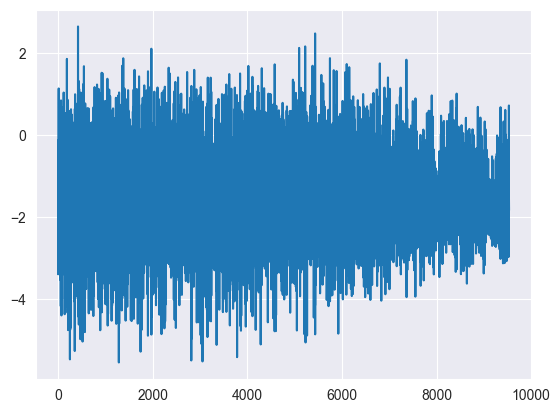

In [447]:
params = model.export()
theta_hat = params["ability"]   # list of num_subjects
b_hat     = params["diff"]      # list of num_items
plt.plot(b_hat)

In [448]:
param_store = pyro.get_param_store()
print(param_store.keys())

# 假設 ability 叫 "theta_loc"，難度叫 "b_loc"（名字要以你印出來的為準）
theta_mean = param_store["loc_ability"].detach().cpu().numpy()
b_mean     = param_store["loc_diff"].detach().cpu().numpy()

dict_keys(['loc_mu_b', 'scale_mu_b', 'loc_mu_theta', 'scale_mu_theta', 'alpha_b', 'beta_b', 'alpha_theta', 'beta_theta', 'loc_ability', 'scale_ability', 'loc_diff', 'scale_diff'])


In [449]:
# 先反轉 mapping
inv_subj_index = {v: k for k, v in subj_index.items()}

theta_df = (
    pd.DataFrame({
        "subject_idx": np.arange(num_subjects),
        "theta": theta_mean,
    })
    .assign(subject_id=lambda d: d["subject_idx"].map(inv_subj_index))
)

# 拆回 user_id & block_idx
# theta_df[["user_id", "block_idx_str"]] = theta_df["subject_id"].str.split("_b", expand=True)
# theta_df["block_idx"] = theta_df["block_idx_str"].astype(int)
# theta_df = theta_df.drop(columns=["block_idx_str", "subject_idx"])

In [450]:
theta_df

,subject_idx,theta,subject_id
0,0,1.601291,-9221365525345808910_sec-2743459521579766823_b...
1,1,2.096988,-9221365525345808910_sec-2743459521579766823_b...
2,2,1.716771,-9221365525345808910_sec-2743459521579766823_b...
3,3,2.782980,-9221365525345808910_sec-2743459521579766823_b...
4,4,2.464491,-9221365525345808910_sec-2743459521579766823_b...
...,...,...,...
64621,64621,2.364146,9223131428943628703_sec7617291776252867339_b2_...
64622,64622,1.710561,9223131428943628703_sec7617291776252867339_b3_...
64623,64623,1.958874,9223131428943628703_sec7617291776252867339_b4_...
64624,64624,1.673506,9223131428943628703_sec7617291776252867339_b5_...


In [451]:
# expend to origin dataframe
# theta_df = pd.merge(theta_df,df_long,on=['subject_id'],how = 'left')
# subj_sname = { row['subject_id']:row['section_name'] for _,row in  df_long.iterrows() }
# theta_df['section_name'] = theta_df['subject_id'].map(subj_sname)

In [452]:
df_sess_with_theta = df_long.drop_duplicates(subset=['subject_id'])
df_sess_with_theta = df_sess_with_theta.drop(labels=['level_0','index','is_correct','difficulty_level_chunk'],axis = 1)

In [453]:
con = duckdb.connect()

con.register("theta_df", theta_df)
con.register("df_long", df_sess_with_theta)

theta_df_merged = con.execute("""
SELECT t.*, d.*
FROM theta_df t
LEFT JOIN df_long d
  ON t.subject_id = d.subject_id
""").df()

con.close()
theta_df = theta_df_merged

In [454]:
theta_df

,subject_idx,theta,subject_id,user_id,session_id,section_name,gamecharacter_id_mode,difficulty_level,question_id,created_at,...,answer_length,question_id_chunk,is_correct_chunk,chunk_order_,chunk_order,block_idx,qlen,difficulty,hash_section_name,subject_id_1
0,0,1.601291,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 1, 3]",1546381573830368031,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
1,1,2.096988,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 1, 3]",-7150461712085010141,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[-7150461712085010141, 8578864530935037483, 38...","[1, 1, 1]",1,1,1,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
2,2,1.716771,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 2, 1]",-2034665883776618604,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[-2034665883776618604, -4343324293520455965, 5...","[1, 1, 1]",1,2,2,True,"[2, 2, 1]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
3,3,2.782980,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[3, 1, 3]",141690302974453717,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[141690302974453717, -6174332113016812101, 872...","[1, 1, 1]",1,3,3,True,"[3, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
4,4,2.464491,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 3, 1]",9180142222447582851,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[9180142222447582851, 8307537542670073023, 490...","[1, 1, 1]",1,4,4,True,"[1, 3, 1]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64621,64621,2.364146,9223131428943628703_sec7617291776252867339_b2_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[3, 3, 2]",-702315407933284713,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,22,"[-702315407933284713, -702315407933284713, 210...","[1, 1, 1]",1,2,2,True,"[3, 3, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b2_...
64622,64622,1.710561,9223131428943628703_sec7617291776252867339_b3_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[2, 2, 1]",-6625937654912846869,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,22,"[-6625937654912846869, 2107237329892204238, -2...","[1, 1, 1]",1,3,3,True,"[2, 2, 1]",7617291776252867339,9223131428943628703_sec7617291776252867339_b3_...
64623,64623,1.958874,9223131428943628703_sec7617291776252867339_b4_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[1, 2, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,22,"[3347446545753250720, 2573813958519971566, 257...","[1, 1, 1]",1,4,4,True,"[1, 2, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b4_...
64624,64624,1.673506,9223131428943628703_sec7617291776252867339_b5_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[1, 1, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,22,"[3347446545753250720, 3347446545753250720, 257...","[1, 1, 1]",1,5,5,True,"[1, 1, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b5_...


In [455]:
theta_df = theta_df.query('answer_length >= 18')
theta_df

,subject_idx,theta,subject_id,user_id,session_id,section_name,gamecharacter_id_mode,difficulty_level,question_id,created_at,...,answer_length,question_id_chunk,is_correct_chunk,chunk_order_,chunk_order,block_idx,qlen,difficulty,hash_section_name,subject_id_1
0,0,1.601291,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 1, 3]",1546381573830368031,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[1546381573830368031, -6292240633515883796, -5...","[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
1,1,2.096988,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 1, 3]",-7150461712085010141,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[-7150461712085010141, 8578864530935037483, 38...","[1, 1, 1]",1,1,1,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
2,2,1.716771,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 2, 1]",-2034665883776618604,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[-2034665883776618604, -4343324293520455965, 5...","[1, 1, 1]",1,2,2,True,"[2, 2, 1]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
3,3,2.782980,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[3, 1, 3]",141690302974453717,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[141690302974453717, -6174332113016812101, 872...","[1, 1, 1]",1,3,3,True,"[3, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
4,4,2.464491,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 3, 1]",9180142222447582851,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,28,"[9180142222447582851, 8307537542670073023, 490...","[1, 1, 1]",1,4,4,True,"[1, 3, 1]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64621,64621,2.364146,9223131428943628703_sec7617291776252867339_b2_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[3, 3, 2]",-702315407933284713,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,22,"[-702315407933284713, -702315407933284713, 210...","[1, 1, 1]",1,2,2,True,"[3, 3, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b2_...
64622,64622,1.710561,9223131428943628703_sec7617291776252867339_b3_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[2, 2, 1]",-6625937654912846869,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,22,"[-6625937654912846869, 2107237329892204238, -2...","[1, 1, 1]",1,3,3,True,"[2, 2, 1]",7617291776252867339,9223131428943628703_sec7617291776252867339_b3_...
64623,64623,1.958874,9223131428943628703_sec7617291776252867339_b4_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[1, 2, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,22,"[3347446545753250720, 2573813958519971566, 257...","[1, 1, 1]",1,4,4,True,"[1, 2, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b4_...
64624,64624,1.673506,9223131428943628703_sec7617291776252867339_b5_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[1, 1, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,22,"[3347446545753250720, 3347446545753250720, 257...","[1, 1, 1]",1,5,5,True,"[1, 1, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b5_...


In [456]:
theta_df.value_counts(['user_id','section_name'])

user_id               section_name     
 6078808323307094882  6 整數、小數除以整數          80
 6878689754289393539  8 平行四邊形、三角形和梯形的面積    69
 6078808323307094882  3 擴分、約分和通分           66
 9207202658248594289  1 多位小數與加減            66
 1735191248007856003  1 體積                 66
                                           ..
-2353185284027581572  7 整數四則運算              6
-2343986178730639688  3 扇形                  6
                      8 比率和百分率              6
-2332196276222035101  1 多位小數                6
-14376048125788679    4 擴分、約分和通分            6
Name: count, Length: 6880, dtype: int64

In [457]:
theta_df['prev_theta'] = theta_df.groupby('user_id')['theta'].shift(1)
theta_df['diff_theta'] = theta_df['theta'] - theta_df['prev_theta']

In [458]:
theta_df

,subject_idx,theta,subject_id,user_id,session_id,section_name,gamecharacter_id_mode,difficulty_level,question_id,created_at,...,is_correct_chunk,chunk_order_,chunk_order,block_idx,qlen,difficulty,hash_section_name,subject_id_1,prev_theta,diff_theta
0,0,1.601291,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 1, 3]",1546381573830368031,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,NaN,NaN
1,1,2.096988,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 1, 3]",-7150461712085010141,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,1,1,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,1.601291,0.495698
2,2,1.716771,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 2, 1]",-2034665883776618604,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,2,2,True,"[2, 2, 1]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,2.096988,-0.380217
3,3,2.782980,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[3, 1, 3]",141690302974453717,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,3,3,True,"[3, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,1.716771,1.066209
4,4,2.464491,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 3, 1]",9180142222447582851,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,4,4,True,"[1, 3, 1]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,2.782980,-0.318489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64621,64621,2.364146,9223131428943628703_sec7617291776252867339_b2_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[3, 3, 2]",-702315407933284713,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,"[1, 1, 1]",1,2,2,True,"[3, 3, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b2_...,-2.031693,4.395838
64622,64622,1.710561,9223131428943628703_sec7617291776252867339_b3_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[2, 2, 1]",-6625937654912846869,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,"[1, 1, 1]",1,3,3,True,"[2, 2, 1]",7617291776252867339,9223131428943628703_sec7617291776252867339_b3_...,2.364146,-0.653585
64623,64623,1.958874,9223131428943628703_sec7617291776252867339_b4_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[1, 2, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,"[1, 1, 1]",1,4,4,True,"[1, 2, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b4_...,1.710561,0.248314
64624,64624,1.673506,9223131428943628703_sec7617291776252867339_b5_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[1, 1, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,"[1, 1, 1]",1,5,5,True,"[1, 1, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b5_...,1.958874,-0.285368


-0.634619
0.014885309
0.0035551493
0.024476921
0.03605343
0.12767565


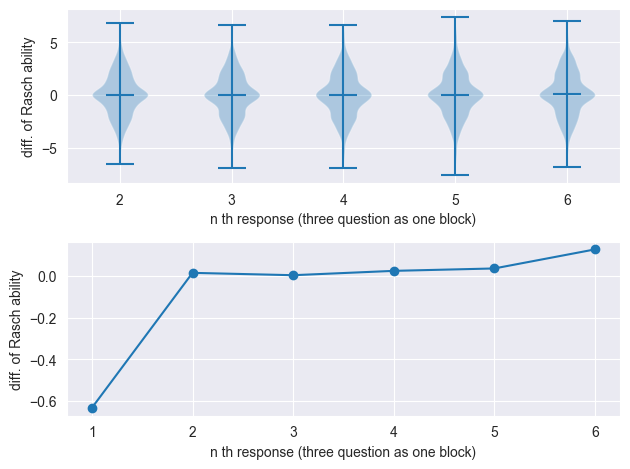

In [459]:
plot_df = (
    theta_df
    # .query("block_idx < 100")
    .sort_values("block_idx")
)

fig,(ax1,ax2) = plt.subplots(2,1)


blocks = [plot_df.query(f'block_idx == {i}').diff_theta for i in range(6)]
for df in blocks:
    print(df.mean())


# plt.scatter(plot_df["block_idx"], plot_df["diff_theta"], marker="o", s = 1)
ax1.violinplot(blocks,showmedians=True)
ax1.set_xlabel("n th response (three question as one block)")
ax1.set_ylabel("diff. of Rasch ability")

pts = [theta_df.query(f'block_idx == {i}').diff_theta.mean() for i in range(6)]
ax2.plot([i+1 for i in range(6)],pts, marker="o")
ax2.set_xlabel("n th response (three question as one block)")
ax2.set_ylabel("diff. of Rasch ability")
plt.tight_layout()
plt.show()




-0.17339969
-0.15851437
-0.15495923
-0.13048232
-0.09442888
0.033272866


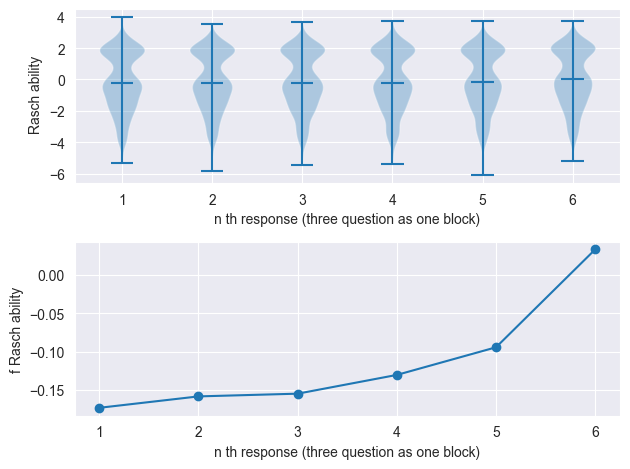

In [460]:
plot_df = (
    theta_df
    # .query("block_idx < 100")
    .sort_values("block_idx")
)

fig,(ax1,ax2) = plt.subplots(2,1)

blocks = [plot_df.query(f'block_idx == {i}').theta for i in range(6)]
for df in blocks:
    print(df.mean())


# plt.scatter(plot_df["block_idx"], plot_df["diff_theta"], marker="o", s = 1)
ax1.violinplot(blocks,showmedians=True)
ax1.set_xlabel("n th response (three question as one block)")
ax1.set_ylabel(" Rasch ability")

pts = [theta_df.query(f'block_idx == {i}').theta.mean() for i in range(6)]
ax2.plot([i+1 for i in range(6)],pts, marker="o")
ax2.set_xlabel("n th response (three question as one block)")
ax2.set_ylabel("f Rasch ability")
plt.tight_layout()
plt.show()




# 12/05

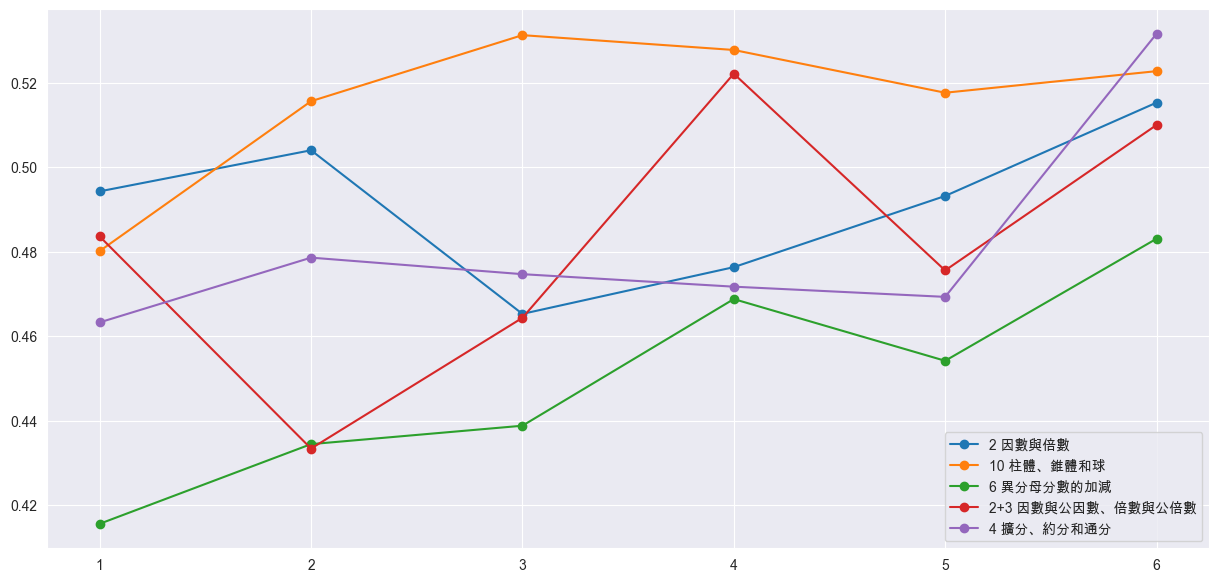

In [461]:
# The predicted correct rate of sections

plt.figure(figsize=(15,7))
plot_df['expected_correct_rate'] = plot_df['theta'].apply(lambda x : np.exp(x)/(1+np.exp(x)))

for section_name in top_section_list[:5]:
    pts = [plot_df.query(f'block_idx == {i} and section_name == "{section_name}"').expected_correct_rate.mean() for i in range(6)]
    errs_orign = [plot_df.query(f'block_idx == {i} and section_name == "{section_name}"').expected_correct_rate.std() for i in range(6)]
    plt.plot([i+1 for i in range(6)],pts, marker="o",label = section_name)
    #plt.fill_between([i+1 for i in range(6)],[pt+er for pt,er in zip(pts,errs)],[pt-er for pt,er in zip(pts,errs)],alpha = 0.3)
plt.legend()
plt.show()

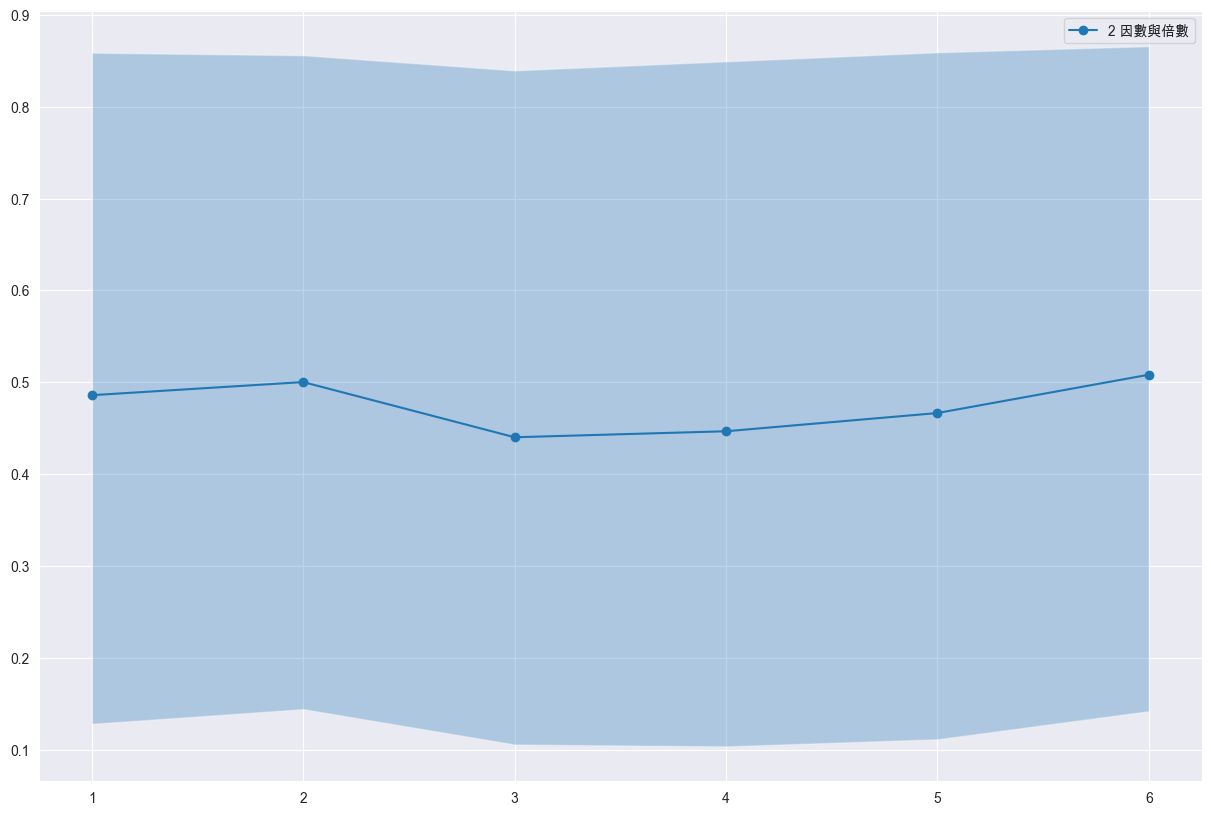

In [462]:
# The predicted correct rate of sections

plt.figure(figsize=(15,10))
plot_df['expected_correct_rate'] = plot_df['theta'].apply(lambda x : np.exp(x)/(1+np.exp(x)))

for section_name in top_section_list[:1]:
    pts = [plot_df.query(f'block_idx == {i} and section_name == "{section_name}"').theta.mean() for i in range(6)]
    errs_orign = [plot_df.query(f'block_idx == {i} and section_name == "{section_name}"').theta.std() for i in range(6)]

    plt.plot([i+1 for i in range(6)],list(map(lambda x : np.exp(x)/(1+np.exp(x)),pts)), marker="o",label = section_name)
    plt.fill_between([i+1 for i in range(6)],
                     list(
                         map(lambda x : np.exp(x)/(1+np.exp(x)) , [pt+er for pt,er in zip(pts,errs_orign)])
                     ),
                     list(
                         map(lambda x : np.exp(x)/(1+np.exp(x)) , [pt-er for pt,er in zip(pts,errs_orign)])
                     )
                    ,alpha = 0.3)
plt.legend()
plt.show()

In [463]:
theta_df

,subject_idx,theta,subject_id,user_id,session_id,section_name,gamecharacter_id_mode,difficulty_level,question_id,created_at,...,is_correct_chunk,chunk_order_,chunk_order,block_idx,qlen,difficulty,hash_section_name,subject_id_1,prev_theta,diff_theta
0,0,1.601291,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 1, 3]",1546381573830368031,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,0,0,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,NaN,NaN
1,1,2.096988,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 1, 3]",-7150461712085010141,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,1,1,True,"[2, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,1.601291,0.495698
2,2,1.716771,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[2, 2, 1]",-2034665883776618604,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,2,2,True,"[2, 2, 1]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,2.096988,-0.380217
3,3,2.782980,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[3, 1, 3]",141690302974453717,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,3,3,True,"[3, 1, 3]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,1.716771,1.066209
4,4,2.464491,-9221365525345808910_sec-2743459521579766823_b...,-9221365525345808910,2.0,1 小數的加減,3047773802229627867,"[1, 3, 1]",9180142222447582851,"[2023-10-06T08:07:44.000000, 2023-10-06T08:08:...",...,"[1, 1, 1]",1,4,4,True,"[1, 3, 1]",-2743459521579766823,-9221365525345808910_sec-2743459521579766823_b...,2.782980,-0.318489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64621,64621,2.364146,9223131428943628703_sec7617291776252867339_b2_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[3, 3, 2]",-702315407933284713,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,"[1, 1, 1]",1,2,2,True,"[3, 3, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b2_...,-2.031693,4.395838
64622,64622,1.710561,9223131428943628703_sec7617291776252867339_b3_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[2, 2, 1]",-6625937654912846869,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,"[1, 1, 1]",1,3,3,True,"[2, 2, 1]",7617291776252867339,9223131428943628703_sec7617291776252867339_b3_...,2.364146,-0.653585
64623,64623,1.958874,9223131428943628703_sec7617291776252867339_b4_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[1, 2, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,"[1, 1, 1]",1,4,4,True,"[1, 2, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b4_...,1.710561,0.248314
64624,64624,1.673506,9223131428943628703_sec7617291776252867339_b5_...,9223131428943628703,8.0,2+3 因數與公因數、倍數與公倍數,7923019900804306903,"[1, 1, 2]",3347446545753250720,"[2024-02-13T04:16:05.000000, 2024-02-13T04:16:...",...,"[1, 1, 1]",1,5,5,True,"[1, 1, 2]",7617291776252867339,9223131428943628703_sec7617291776252867339_b5_...,1.958874,-0.285368


In [464]:
# identify the people have improvement

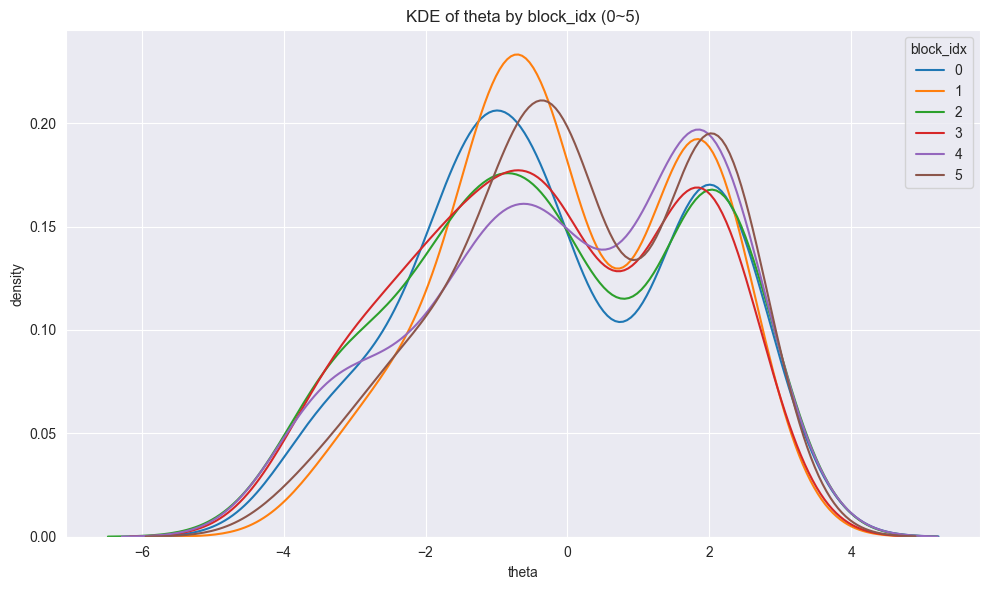

In [465]:
# 選擇章節
person_improve_df = theta_df.query(f'section_name == "{top_section_list[0]}"  and session_id == 1')
person_improve_df = person_improve_df.pivot(index ='user_id', columns='block_idx', values ='theta')
person_improve_df = person_improve_df.reset_index()

# 找 0~5 欄（支援欄名是 int 或 str）
cols_int = [c for c in range(6) if c in person_improve_df.columns]
cols_str = [str(c) for c in range(6) if str(c) in person_improve_df.columns]
cols = cols_int if len(cols_int) == 6 else cols_str

if len(cols) == 0:
    raise ValueError(f"找不到 0~5 欄位，現有欄位：{list(person_improve_df.columns)}")

plt.figure(figsize=(10, 6))

for c in cols:
    x = person_improve_df[c].dropna()
    sns.kdeplot(x=x, label=str(c), fill=False, common_norm=False)  # 疊在同圖

plt.xlabel("theta")
plt.ylabel("density")
plt.title("KDE of theta by block_idx (0~5)")
plt.legend(title="block_idx")
plt.tight_layout()
plt.show()

In [466]:
person_improve_df

block_idx,user_id,0,1,2,3,4,5,6,7,8,...,36,37,38,39,40,41,42,43,44,45
0,-9121290411414837567,-0.333755,-0.729043,1.542863,-0.013325,-1.514320,-0.030959,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-9039835021856617649,-2.200830,-1.149590,-1.573393,-2.474016,-1.071750,1.768967,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8998572465591804129,2.212934,1.561953,2.215477,1.920849,2.449283,2.292255,2.114814,2.596775,-3.429289,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-8874500968526129111,0.106829,-0.230299,1.770200,-0.099398,1.903502,2.183627,1.689918,2.191313,2.172467,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-8211933074113731597,-0.923813,-0.635505,0.009924,-2.766649,2.533976,-0.027700,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,8457288340251087892,-2.033978,1.631523,1.636540,-0.257669,0.106147,-0.777868,1.897462,-4.474544,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136,8648853609903862300,0.302881,-3.269345,-1.743209,-1.944256,2.087528,2.391736,-2.208641,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
137,8653748270246281859,-1.042632,-0.818197,-1.268480,1.124257,2.076871,-1.327267,-2.757191,0.934804,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138,9032719759810907333,2.641355,1.872905,-0.196138,-3.301441,1.897027,2.321842,1.829375,1.599384,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


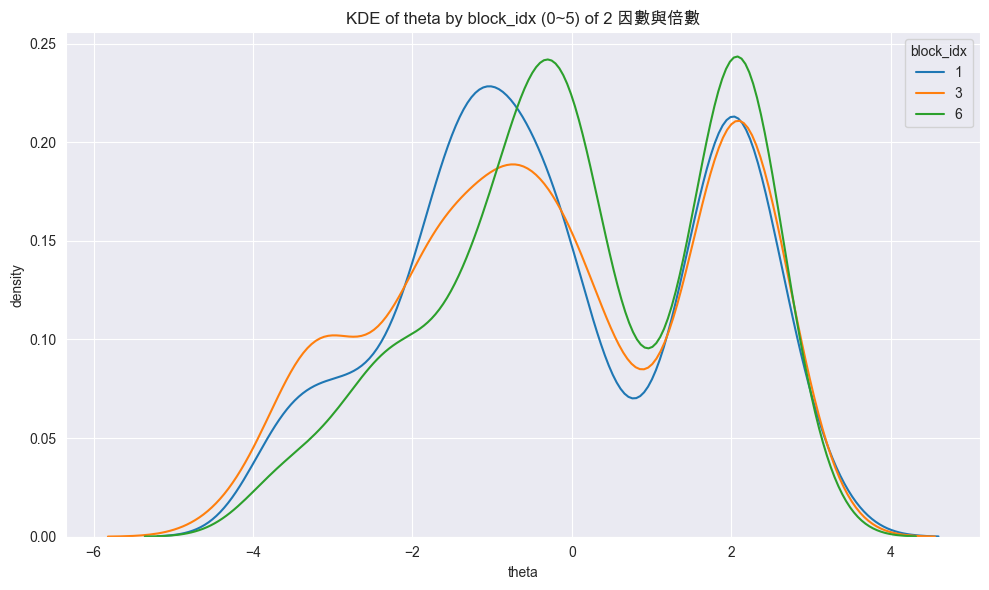

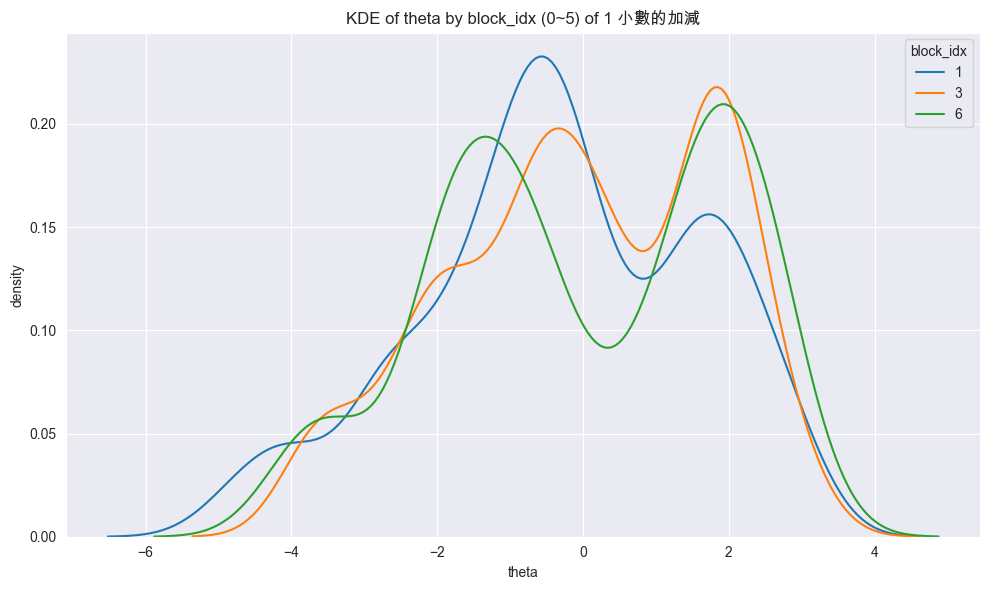

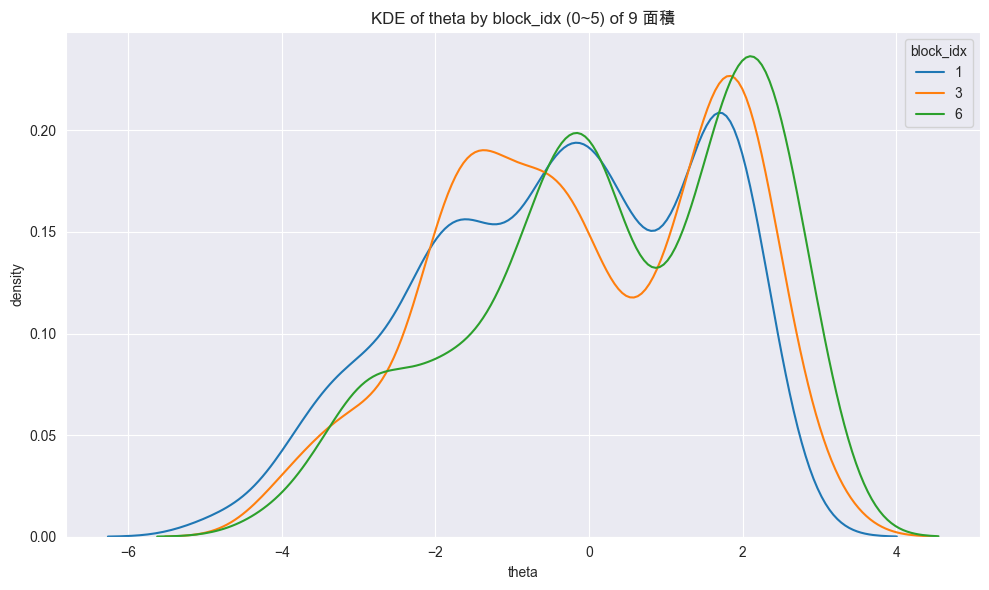

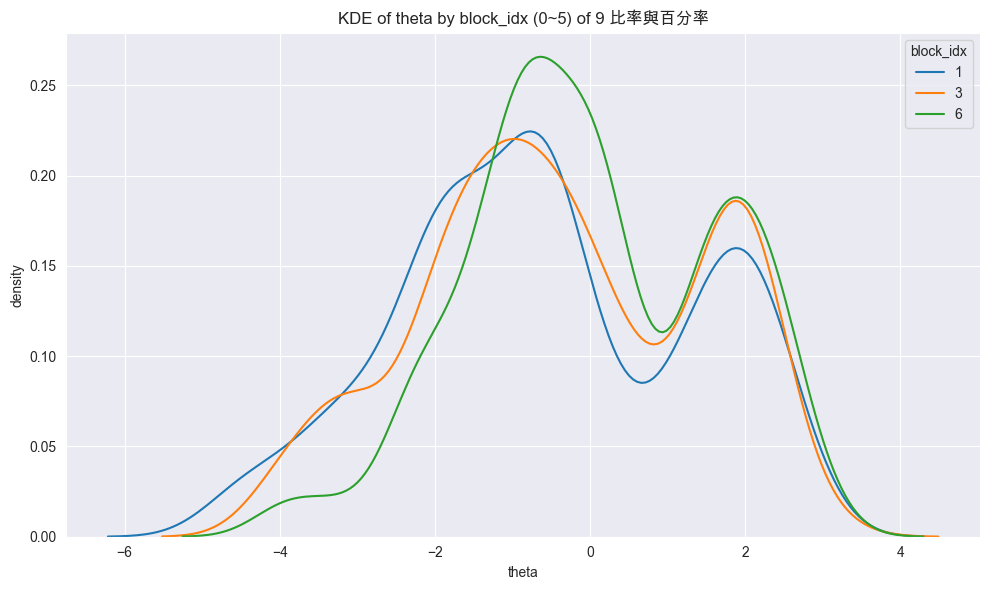

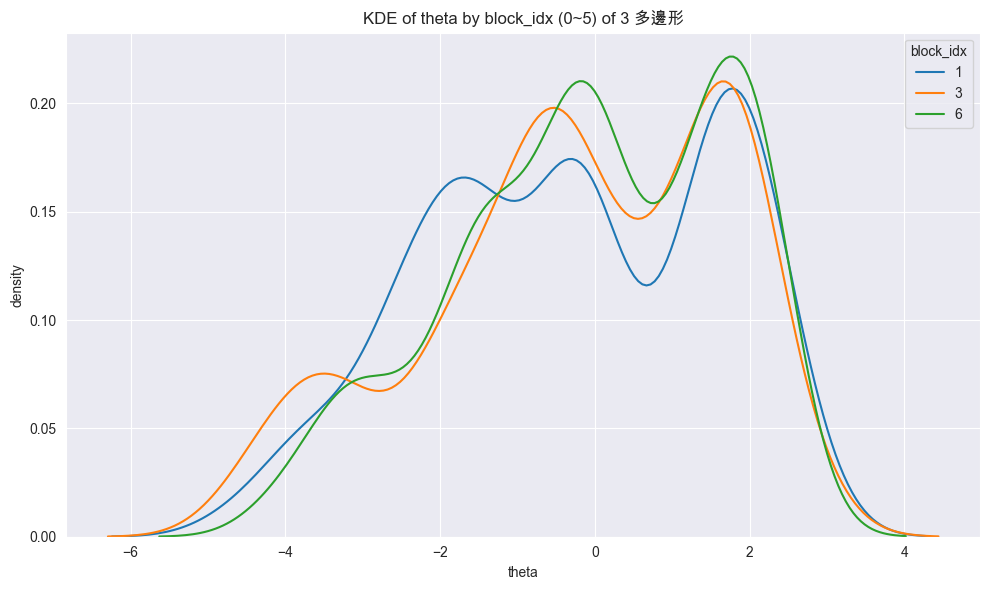

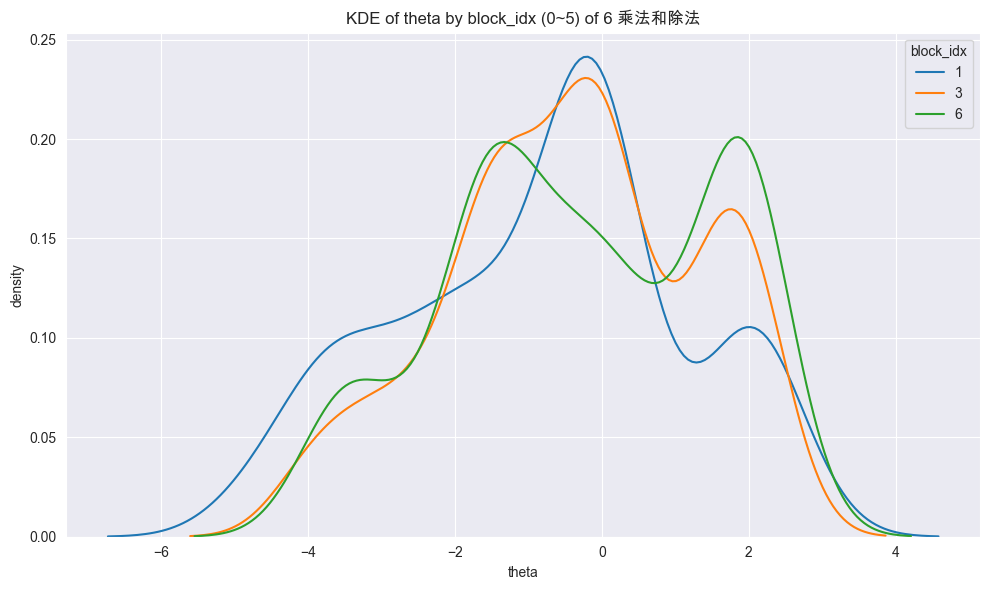

In [467]:
for top_n in range(0,30,5):
    person_improve_df = theta_df.query(f'section_name == "{top_section_list[top_n]}" and block_idx <= 10 and session_id == 1')
    person_improve_df = person_improve_df.pivot(index ='user_id', columns='block_idx', values ='theta')
    person_improve_df = person_improve_df.reset_index()

    # 找 0~5 欄（支援欄名是 int 或 str）
    cols = [0,2,5]

    if len(cols) == 0:
        raise ValueError(f"找不到 0~5 欄位，現有欄位：{list(person_improve_df.columns)}")

    plt.figure(figsize=(10, 6))

    for c in cols:
        x = person_improve_df[c].dropna()
        sns.kdeplot(x=x, label=str(c+1), fill=False,bw_adjust=0.7)

    plt.xlabel("theta")
    plt.ylabel("density")
    plt.title(f"KDE of theta by block_idx (0~5) of {top_section_list[top_n]}")
    plt.legend(title="block_idx")
    plt.tight_layout()
    plt.show()

In [722]:
import numpy as np

# 1) 每人每 section 計算 improve = theta(b5) - theta(b0)
tmp = theta_df.query('session_id == 1').copy()

wide = (tmp
        .pivot(index=['user_id','section_name'], columns='block_idx', values='theta')
        .rename(columns={0:'b0', 5:'b5'})
        .dropna(subset=['b0','b5'])
       )

wide['improve'] = wide['b5'] - wide['b0']
wide = wide.reset_index()

# 2) user × section 的 improve 矩陣
M = wide.pivot(index='user_id', columns='section_name', values='improve')

# 3) 檢查：每個人做過幾個 section（如果大多=1，就沒法算跨 section 相關）
print("每人有幾個 section：")
print(M.notna().sum(axis=1).value_counts().sort_index().head(20))

# 4) overlap（兩個 section 同時有資料的 user 數）
mask = M.notna().astype(int)
overlap = mask.T @ mask   # (section × section)

# 5) 相關性（只用有交集的人；min_periods 要自己設定）
corr = M.corr(method='pearson', min_periods=3)

# 6) 把「可用的 section pair」整理成表（含 overlap）
tri = np.triu(np.ones(corr.shape), 1).astype(bool)
pairs = (corr.where(tri).stack().dropna().to_frame('corr'))
pairs['n_overlap'] = [int(overlap.loc[i, j]) for i, j in pairs.index]
pairs = pairs.sort_values(['n_overlap','corr'], ascending=[False, False])

print("\n跨 section 的相關（依 overlap 優先排序）：")
pairs = pairs.sort_values('n_overlap')
pairs

每人有幾個 section：
1     1660
2      396
3      154
4       89
5       60
6       33
7       15
8        7
9        4
10       5
11       2
12       7
13       2
14       1
15       1
16       1
19       1
Name: count, dtype: int64

跨 section 的相關（依 overlap 優先排序）：


,,corr,n_overlap
section_name,section_name,,
10 立體形體,8 四則運算,-0.998903,3
1 小數的加減,8 表面積,0.841791,3
10 小數的加減,4 正方體和長方體,0.828764,3
1 乘法和除法,5 線對稱圖形,0.828442,3
10 生活中的單位與換算,8 面積,0.814111,3
...,...,...,...
10 柱體、錐體和球,7 線對稱圖形,-0.006290,26
10 立體形體,6 表面積,0.099748,26
2+3 因數與公因數、倍數與公倍數,5 多邊形與扇形,0.386637,26


In [723]:
vals = pairs['corr'].to_list()
weight = pairs.n_overlap.to_list()
weight_mean = np.average(vals,weights= weight)
weight_mean

0.07376138218749294

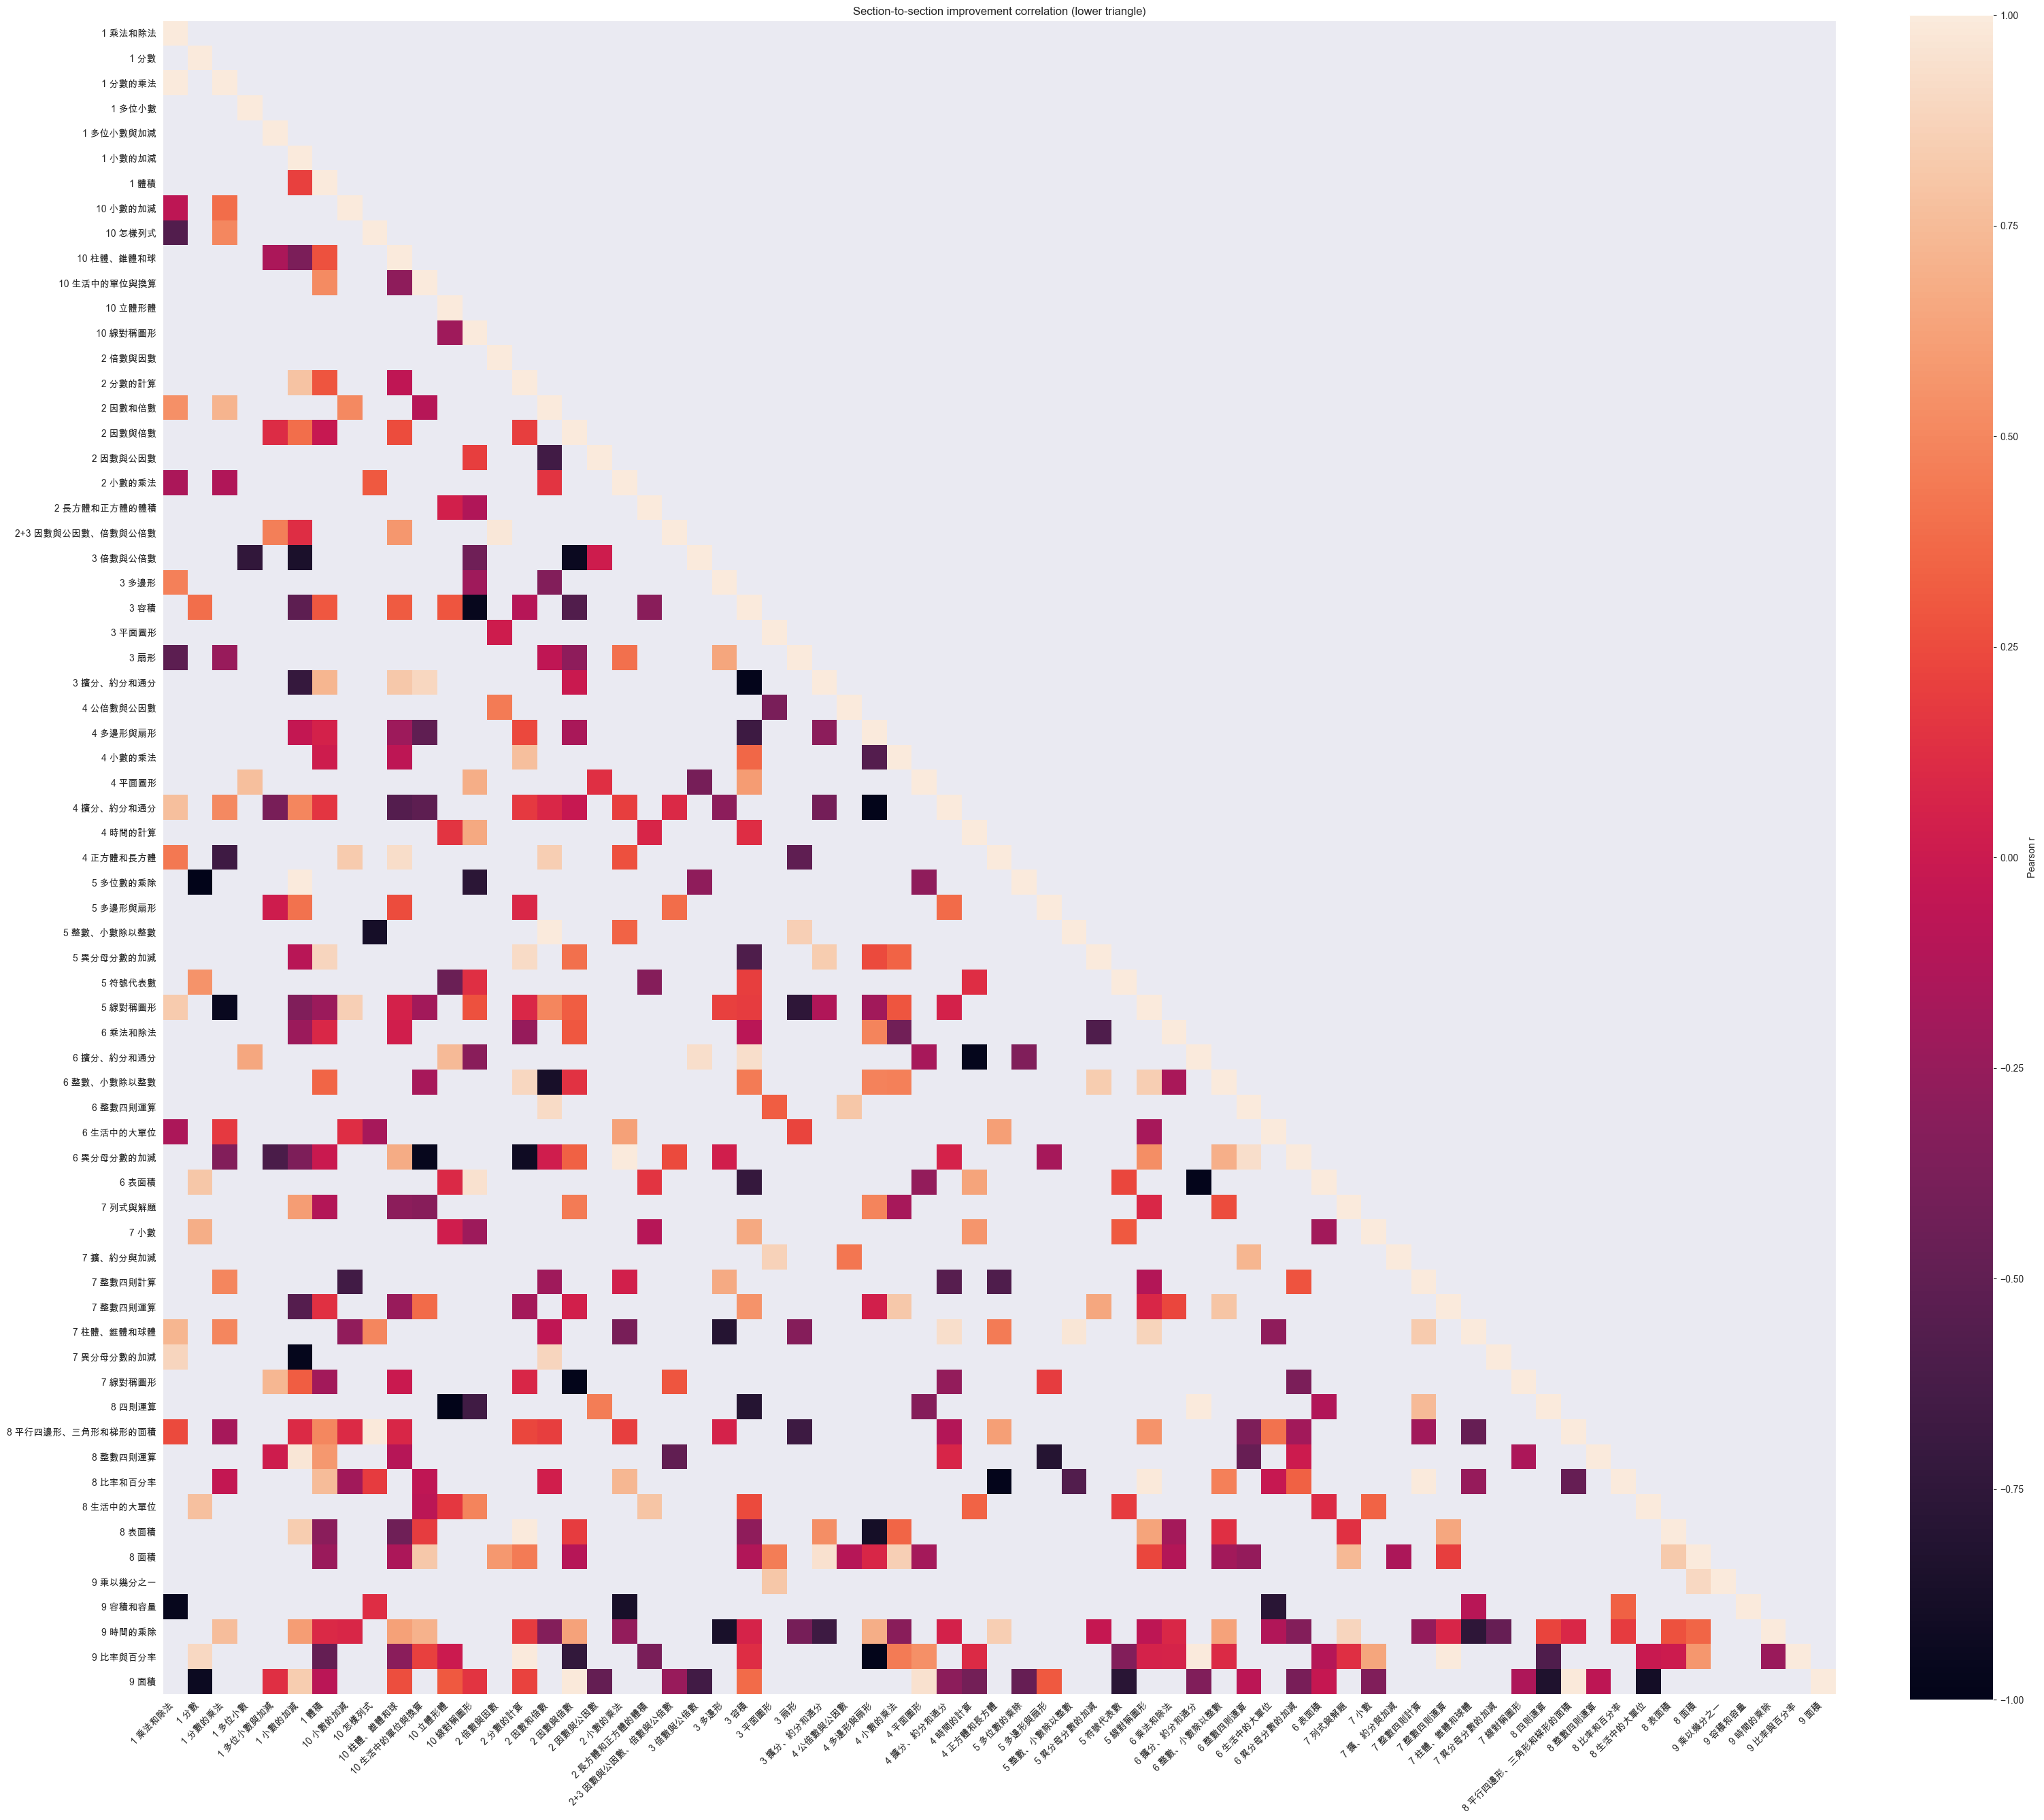

In [724]:
corr_lower = corr.copy()
mask = np.triu(np.ones(corr_lower.shape), k=1).astype(bool)  # 上三角 True
corr_lower.values[mask] = np.nan

n = corr_lower.shape[0]
fig, ax = plt.subplots(figsize=(max(8, 0.45*n), max(6, 0.45*n)))

im = ax.imshow(np.ma.masked_invalid(corr_lower.values), vmin=-1, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr_lower.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_lower.index)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r")

ax.set_title("Section-to-section improvement correlation (lower triangle)")
plt.tight_layout()
plt.grid(False)
plt.show()

# Define the improvement

In [725]:
person_improve_df = theta_df.query('session_id == 1').copy()
person_improve_df = person_improve_df.groupby(['user_id', 'section_name'], as_index=False).agg(
    session_id=('session_id', 'first'),
    thetas=('theta', list),
    ans_length = ('answer_length','first'),
    total_time = ('time_diff','first'),
    first18_time = ('time_diff','first' )
)
person_improve_df['total_time'] = person_improve_df['total_time'].apply(lambda lis:lis[1:])
person_improve_df['first18_time'] = person_improve_df['first18_time'].apply(lambda lis:lis[1:18])
person_improve_df['improve'] = person_improve_df['thetas'].apply(lambda lis: lis[5] - lis[0])
person_improve_df['avg_time18'] = person_improve_df['first18_time'].apply(lambda lis: lis.mean() / 17)
person_improve_df['avg_time'] = person_improve_df.apply(lambda row : row['total_time'].mean() / (row['ans_length'] - 1), axis = 1)

# 01/02

In [727]:
improve_df = wide.groupby('user_id').agg(
    Num_of_section = ('improve', 'count'),
    Num_of_improve = ('improve', lambda lis: sum(1 for _ in lis if _ > 0))
).reset_index()

In [728]:
len(improve_df.query('Num_of_section > 2').index)

382

In [729]:
improve_df.value_counts('Num_of_section')

Num_of_section
1     1660
2      396
3      154
4       89
5       60
6       33
7       15
12       7
8        7
10       5
9        4
11       2
13       2
14       1
15       1
16       1
19       1
Name: count, dtype: int64

In [730]:
improve_df.query("Num_of_section > 2")

,user_id,Num_of_section,Num_of_improve
1,-9197559111519444133,4,1
7,-9121290411414837567,3,2
10,-9061858609649183032,5,2
13,-9039835021856617649,3,3
14,-9025632755565353692,3,1
...,...,...,...
2408,8945785762938221928,6,3
2423,9068041036298843033,6,2
2424,9078864250911715241,3,1
2428,9155877033299212141,3,2


In [731]:
improve_df.loc[:,'ratio_of_improvement'] = improve_df.apply(lambda row : row['Num_of_improve']/row['Num_of_section'],axis = 1)


Text(0.5, 0, 'Percentile of improve')

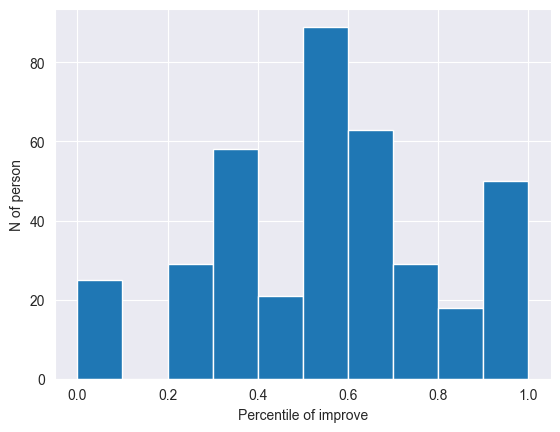

In [750]:
improve_df.query('Num_of_section > 2')['ratio_of_improvement'].hist(bins = 10)
plt.ylabel('N of person')
plt.xlabel('Percentile of improve')


<Axes: xlabel='ratio_of_improvement', ylabel='Density'>

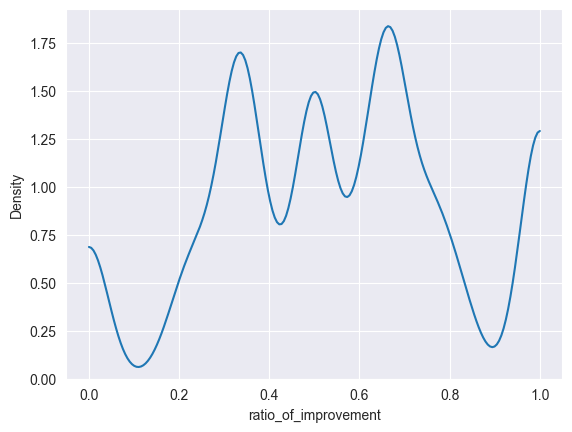

In [758]:


sns.kdeplot(x=improve_df.query('7 > Num_of_section > 2')['ratio_of_improvement'],bw_adjust=.5,cut=0)  # 疊在同圖


average improve rate 0.5403


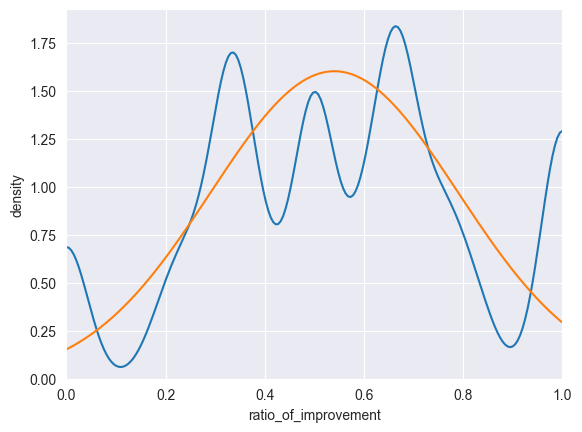

In [757]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 平均改善比例（>0 視為改善）
avg = (wide["improve"] > 0).mean()
print(f"average improve rate {avg:.4f}")

# 2) KDE（同圖）
data = improve_df.query("7 > Num_of_section > 2")["ratio_of_improvement"].dropna()

ax = sns.kdeplot(x=data, bw_adjust=0.5, cut=0)

# 3) 疊一條常態近似曲線（請把 n_trials 改成你想近似的樣本/試次數）
n_trials = 4
sigma = np.sqrt(avg * (1 - avg) / n_trials)

x = np.linspace(0, 1, 1000)
y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - avg) / sigma) ** 2)

ax.plot(x, y)

ax.set_xlim(0, 1)
ax.set_xlabel("ratio_of_improvement")
ax.set_ylabel("density")
plt.show()

<Axes: xlabel='ratio_of_improvement', ylabel='Proportion'>

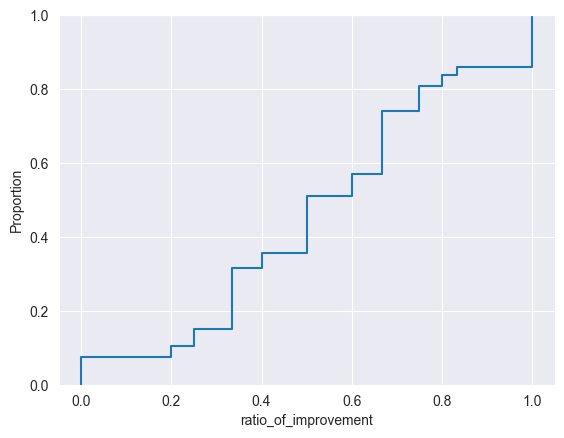

In [734]:
sns.ecdfplot(x=improve_df.query('7 > Num_of_section > 2')['ratio_of_improvement'])

<Axes: xlabel='Num_of_section', ylabel='ratio_of_improvement'>

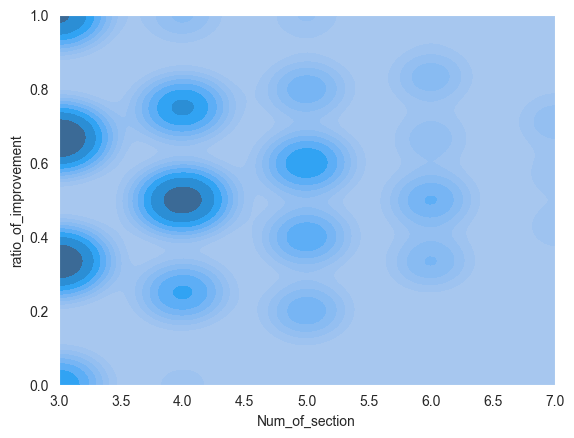

In [735]:
sns.kdeplot(improve_df.query('8 > Num_of_section > 2'),y='ratio_of_improvement',x='Num_of_section',bw_adjust=0.5,cut=0,fill=True,thresh=0)

In [736]:
improve_df.query('Num_of_section >= 2').value_counts('ratio_of_improvement')

ratio_of_improvement
0.500000    245
1.000000    164
0.000000    120
0.666667     59
0.333333     57
0.750000     24
0.600000     23
0.250000     16
0.400000     16
0.800000     10
0.200000     10
0.833333      7
0.714286      5
0.428571      3
0.571429      3
0.285714      2
0.625000      1
0.700000      1
0.857143      1
0.642857      1
0.562500      1
0.615385      1
0.545455      1
0.538462      1
0.526316      1
0.222222      1
0.454545      1
0.416667      1
0.375000      1
0.555556      1
Name: count, dtype: int64

In [737]:
wide.improve.apply(lambda x:1 if x>0 else 0).mean()

0.5402517216813109

## label the improvers

In [738]:
improve_df

,user_id,Num_of_section,Num_of_improve,ratio_of_improvement
0,-9205211803322048842,1,1,1.00
1,-9197559111519444133,4,1,0.25
2,-9193028651344612307,1,0,0.00
3,-9191260485172792685,2,1,0.50
4,-9171924025615106864,1,0,0.00
...,...,...,...,...
2433,9199601425824629864,2,0,0.00
2434,9207202658248594289,1,0,0.00
2435,9207429689707212922,2,1,0.50
2436,9213989164981202622,2,1,0.50


In [739]:
improve_df['is_improver'] = improve_df.apply(lambda row : np.nan if row['Num_of_section'] <= 2 else (1 if row['ratio_of_improvement'] > 0.75 else 0),axis = 1)

In [740]:
temp = improve_df.loc[:,['user_id','is_improver']]

In [741]:
person_improve_df.groupby('user_id').agg(
    total_time = ('total_time',list),
    first18_time = ('first18_time',list),
    ans_length = ('ans_length',list)
)
person_improve_df = person_improve_df.merge(temp,how='left',on='user_id')

In [742]:
person_improve_df.groupby('is_improver')[['ans_length','avg_time','avg_time18']].agg(['mean','std'])

ans_length             avg_time           avg_time18          
                  mean        std      mean       std       mean       std
is_improver                                                               
0.0          33.584407  21.382544  1.725894  1.534786   2.661399  2.041226
1.0          26.461268  10.262039  2.041880  1.509370   2.834799  1.826551

<Axes: xlabel='avg_time18', ylabel='Density'>

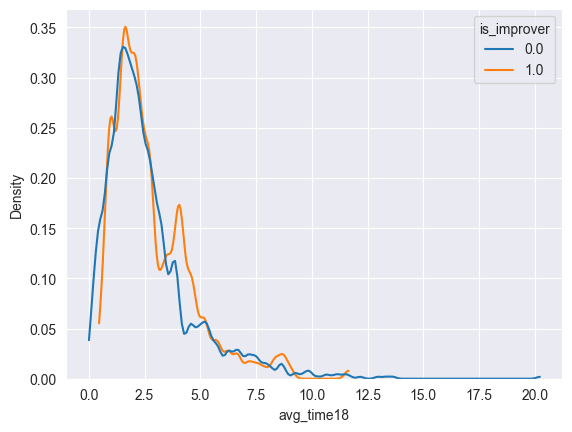

In [743]:
sns.kdeplot(data = person_improve_df,x = 'avg_time18',hue = 'is_improver',common_norm=False,bw_adjust=0.3,cut = 0)

<Axes: xlabel='ans_length', ylabel='Density'>

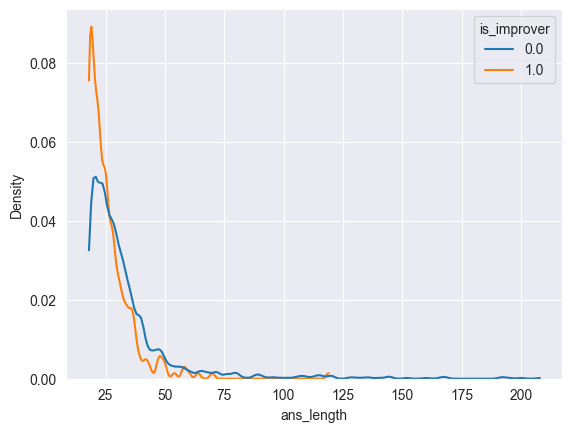

In [744]:
sns.kdeplot(data = person_improve_df,x = 'ans_length',hue = 'is_improver',common_norm=False,bw_adjust=0.3,cut = 0)

<Axes: xlabel='ans_length', ylabel='avg_time18'>

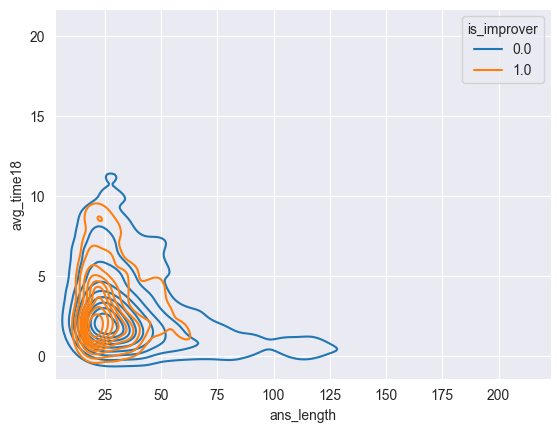

In [745]:
sns.kdeplot(data = person_improve_df,x = 'ans_length',y = 'avg_time18',hue = 'is_improver',common_norm=False,bw_adjust=0.8)

In [746]:
person_improve_long_df = person_improve_df[['first18_time','is_improver']].copy()
for col in range(17):
    person_improve_long_df[f'{col+2}'] = person_improve_df['first18_time'].apply(lambda lis:  lis[col])
person_improve_long_df = person_improve_long_df.drop('first18_time',axis = 1)
person_improve_long_df = person_improve_long_df.fillna(-1)

<Figure size 700x1400 with 0 Axes>

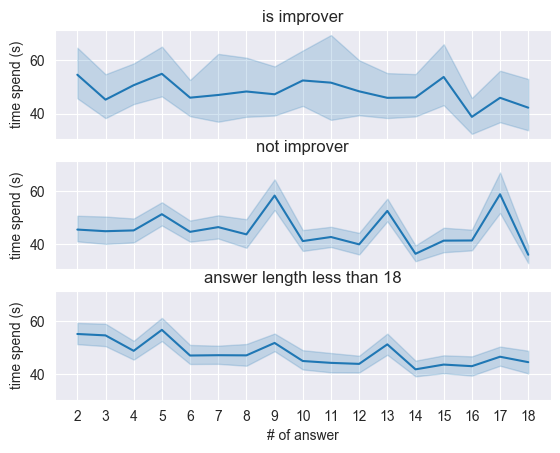

In [747]:
import matplotlib as mpl
plt.figure(figsize=(7,14))
fig,axs = plt.subplots(3,1,sharey= True,sharex=True)
tempdf = person_improve_long_df.melt(id_vars=['is_improver'])
for cate,ax in zip([1,0,-1],axs):
    sns.lineplot(data = tempdf.query(f"is_improver == {cate}"), x = 'variable',y = 'value',ax=ax)
    ax.set_title(f"{'is improver' if cate == 1 else ('not improver' if cate == 0 else 'answer length less than 18') }")
    ax.set_ylabel('time spend (s)')
    ax.set_xlabel('# of answer')


<Axes: xlabel='variable', ylabel='value'>

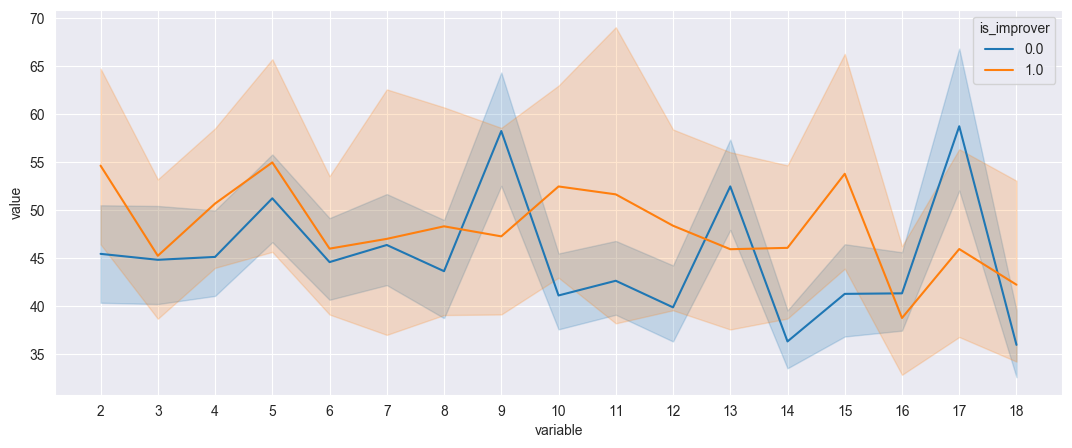

In [748]:
plt.figure(figsize=(13,5))
sns.lineplot(data = tempdf.query('is_improver != -1'), x = 'variable',y = 'value',hue = 'is_improver')

# section based analyze


In [760]:
improve_df_section = wide.groupby('section_name').agg(
    Num_of_section = ('improve', 'count'),
    Num_of_improve = ('improve', lambda lis: sum(1 for _ in lis if _ > 0))
).reset_index()

In [761]:
improve_df_section

,section_name,Num_of_section,Num_of_improve
0,1 乘法和除法,42,21
1,1 分數,23,13
2,1 分數的乘法,55,32
3,1 多位小數,36,18
4,1 多位小數與加減,77,39
...,...,...,...
62,9 乘以幾分之一,9,5
63,9 容積和容量,31,17
64,9 時間的乘除,82,42
65,9 比率與百分率,126,77
